# 🏥 Medical Symptom Analyzer — EDA & Model Training
**Dataset:** Disease Symptom Description — Kaggle
**Model:** Random Forest Classifier
Run all cells top to bottom. At the end, `model.pkl` and `label_encoder.pkl` will be downloaded automatically.

In [4]:
# CELL 1 — Install dependencies
!pip install scikit-learn pandas numpy matplotlib seaborn joblib -q

In [5]:
# CELL 2 — Upload dataset files
from google.colab import files
print('Upload these 4 files from your data/ folder:')
print('  dataset.csv, symptom_Description.csv, symptom_precaution.csv, Symptom-severity.csv')
uploaded = files.upload()

Upload these 4 files from your data/ folder:
  dataset.csv, symptom_Description.csv, symptom_precaution.csv, Symptom-severity.csv


Saving dataset.csv to dataset (2).csv
Saving symptom_Description.csv to symptom_Description (1).csv
Saving symptom_precaution.csv to symptom_precaution (1).csv
Saving Symptom-severity.csv to Symptom-severity (1).csv


In [6]:
# CELL 3 — Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('Libraries imported successfully!')

Libraries imported successfully!


In [10]:
# CELL 4 — Load dataset (FIXED for this format)
df = pd.read_csv('dataset.csv')
desc_df = pd.read_csv('symptom_Description.csv')
prec_df = pd.read_csv('symptom_precaution.csv')
sev_df  = pd.read_csv('Symptom-severity.csv')

# Clean column names
df.columns = df.columns.str.strip()

print('Shape:', df.shape)
print('Diseases:', df['Disease'].nunique())
df.head(3)

Shape: (4920, 18)
Diseases: 41


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


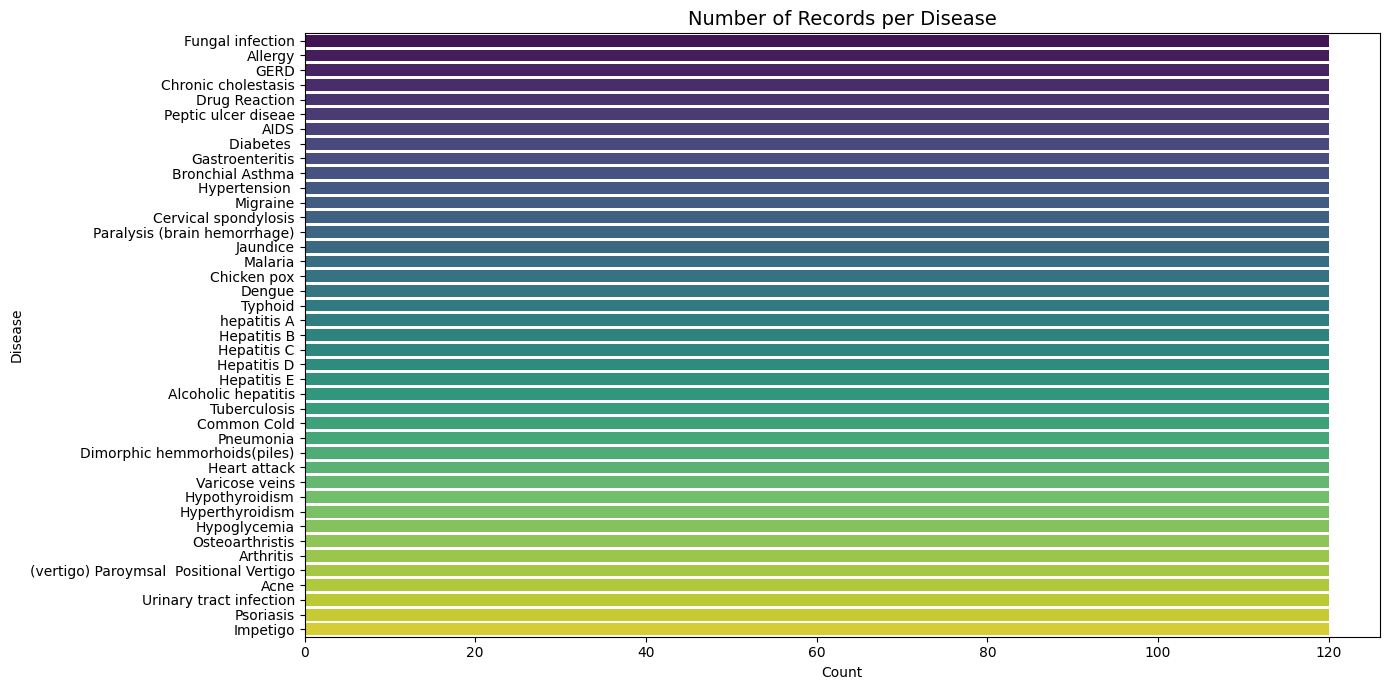

Total diseases: 41


In [11]:
# CELL 5 — EDA: Disease distribution
plt.figure(figsize=(14, 7))
disease_counts = df['Disease'].value_counts()
sns.barplot(x=disease_counts.values, y=disease_counts.index, palette='viridis')
plt.title('Number of Records per Disease', fontsize=14)
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('disease_distribution.png', dpi=150)
plt.show()
print('Total diseases:', len(disease_counts))

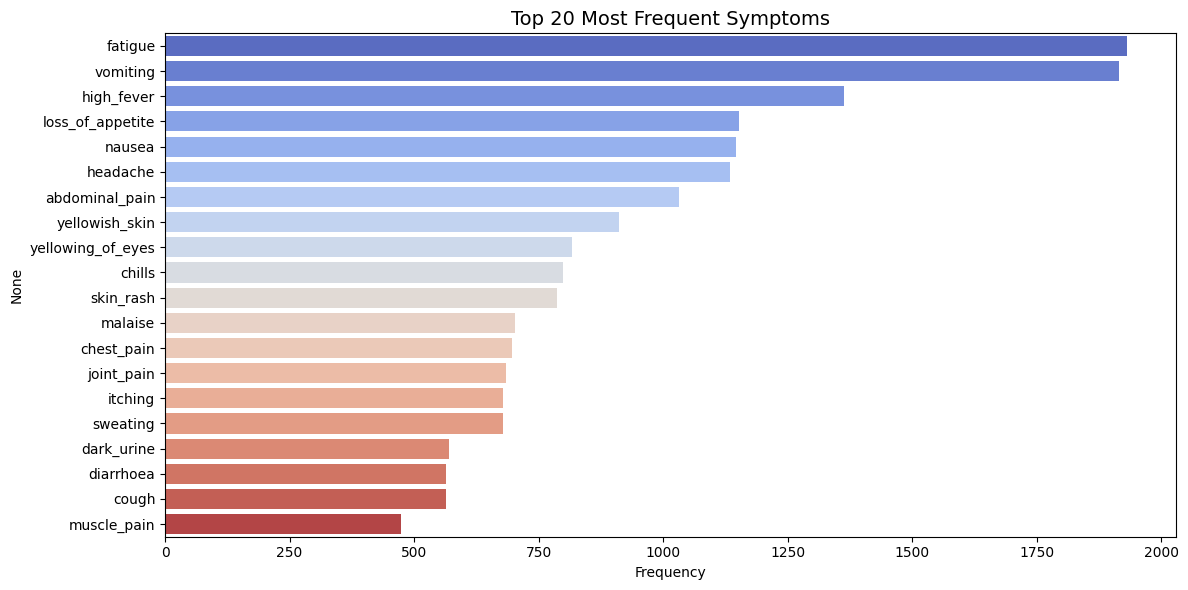

In [12]:
# CELL 6 — EDA: Top 20 most common symptoms
symptom_cols = ['Symptom_1','Symptom_2','Symptom_3','Symptom_4','Symptom_5',
                'Symptom_6','Symptom_7','Symptom_8','Symptom_9','Symptom_10',
                'Symptom_11','Symptom_12','Symptom_13','Symptom_14','Symptom_15',
                'Symptom_16','Symptom_17']

all_symptoms = df[symptom_cols].values.flatten()
all_symptoms = pd.Series(all_symptoms).dropna().str.strip()
top20 = all_symptoms.value_counts().head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top20.values, y=top20.index, palette='coolwarm')
plt.title('Top 20 Most Frequent Symptoms', fontsize=14)
plt.xlabel('Frequency')
plt.tight_layout()
plt.savefig('symptom_frequency.png', dpi=150)
plt.show()

In [13]:
# CELL 7 — Preprocessing: Convert to binary matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

symptom_cols = ['Symptom_1','Symptom_2','Symptom_3','Symptom_4','Symptom_5',
                'Symptom_6','Symptom_7','Symptom_8','Symptom_9','Symptom_10',
                'Symptom_11','Symptom_12','Symptom_13','Symptom_14','Symptom_15',
                'Symptom_16','Symptom_17']

# Get all unique symptoms
all_sym = pd.Series(df[symptom_cols].values.flatten())
all_sym = all_sym.dropna().str.strip().unique().tolist()
all_sym = sorted(set(all_sym))
print('Total unique symptoms:', len(all_sym))

# Binary matrix banao
def encode_row(row):
    vec = {s: 0 for s in all_sym}
    for col in symptom_cols:
        val = str(row[col]).strip() if pd.notna(row[col]) else None
        if val and val in vec:
            vec[val] = 1
    return vec

encoded = df.apply(encode_row, axis=1, result_type='expand')
X = encoded.values
print('X shape:', X.shape)

# Target encode
le = LabelEncoder()
y = le.fit_transform(df['Disease'].str.strip())
print('Classes:', len(le.classes_))

# Save symptom list for app.py
import json
with open('symptom_list.json', 'w') as f:
    json.dump(all_sym, f)
print('symptom_list.json saved!')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('X_train:', X_train.shape, '| X_test:', X_test.shape)

Total unique symptoms: 131
X shape: (4920, 131)
Classes: 41
symptom_list.json saved!
X_train: (3936, 131) | X_test: (984, 131)


In [14]:
# CELL 8 — Train 3 models and compare
models = {
    'Random Forest'  : RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree'  : DecisionTreeClassifier(random_state=42),
    'Naive Bayes'    : GaussianNB()
}

results = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, m.predict(X_train))
    test_acc  = accuracy_score(y_test,  m.predict(X_test))
    cv_score  = cross_val_score(m, X, y, cv=5).mean()
    results[name] = {'Train Acc': train_acc, 'Test Acc': test_acc, 'CV Score': cv_score}
    print(f'{name:20s} | Train: {train_acc:.4f} | Test: {test_acc:.4f} | CV: {cv_score:.4f}')

print('\n✅ Best model: Random Forest')

Random Forest        | Train: 1.0000 | Test: 1.0000 | CV: 1.0000
Decision Tree        | Train: 1.0000 | Test: 1.0000 | CV: 1.0000
Naive Bayes          | Train: 1.0000 | Test: 1.0000 | CV: 1.0000

✅ Best model: Random Forest


In [15]:
# CELL 9 — Detailed evaluation of Random Forest
rf_model = models['Random Forest']
y_pred   = rf_model.predict(X_test)

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        24
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00      1.00        24
                            Common Cold       1.00      1.00      1.00        24
    

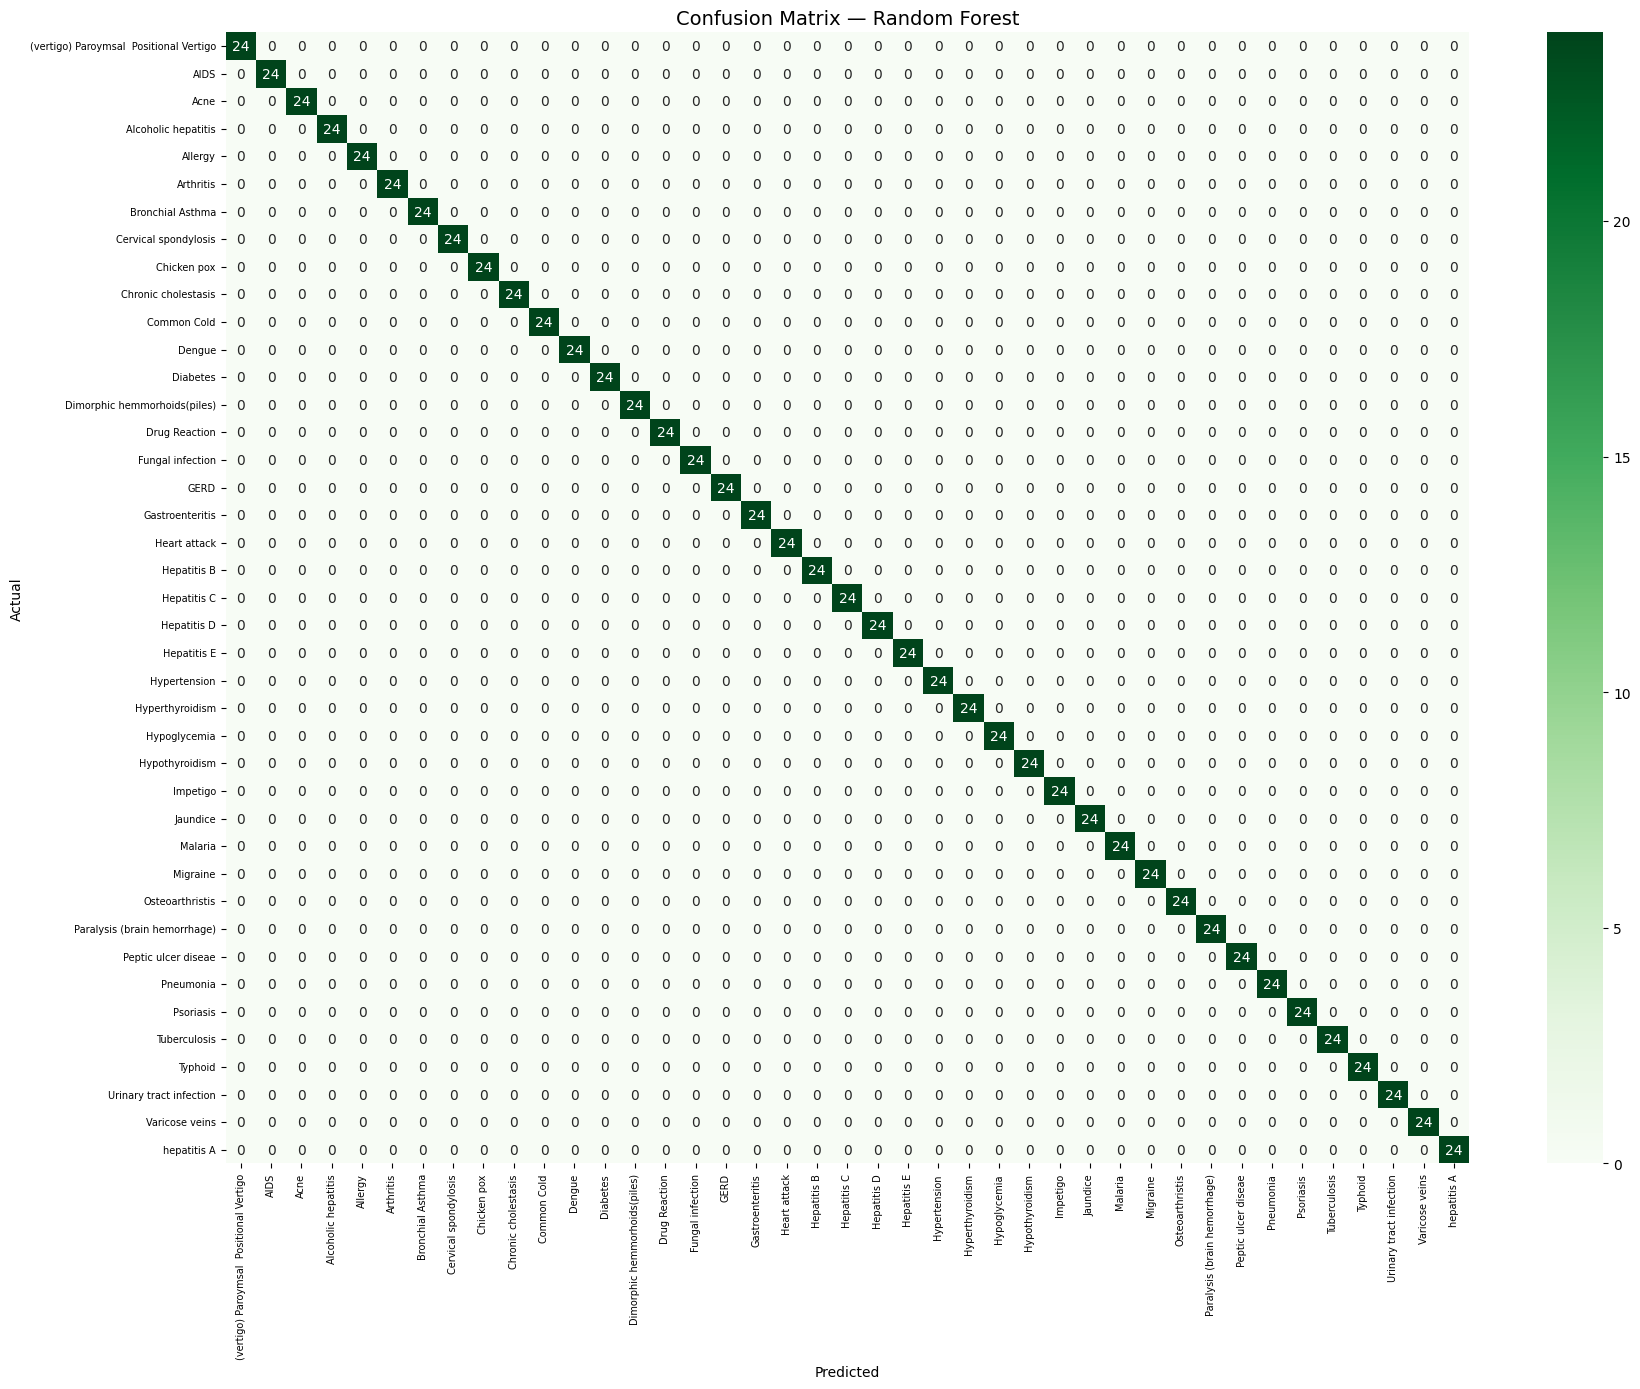

In [16]:
# CELL 10 — Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(18, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Random Forest', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

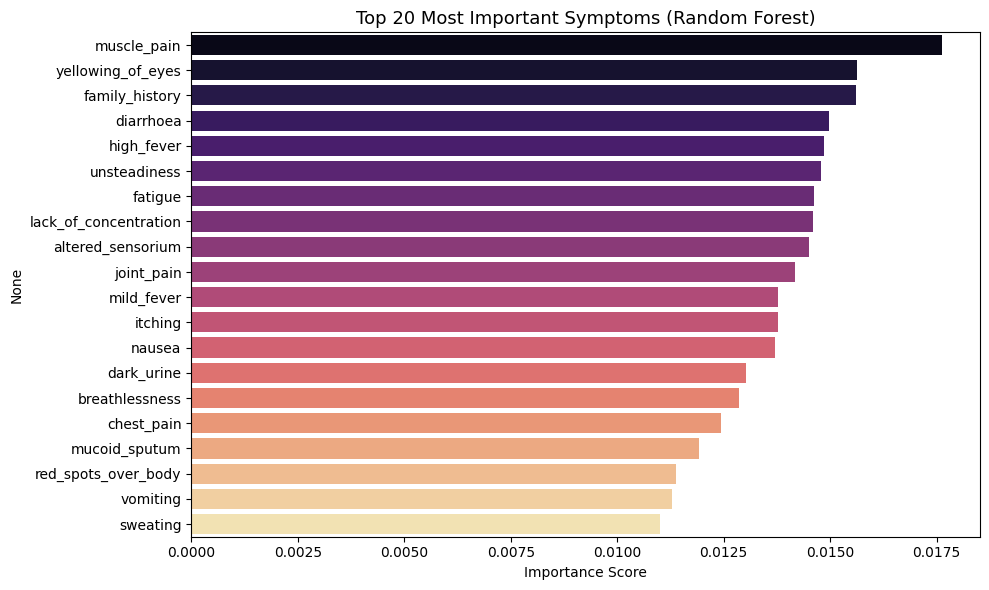

In [19]:
# CELL 11 — Feature importance (FIXED)
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=all_sym).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='magma')
plt.title('Top 20 Most Important Symptoms (Random Forest)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [20]:
# CELL 12 — Save model, encoder AND symptom list
import joblib
joblib.dump(rf_model, 'model.pkl')
joblib.dump(le, 'label_encoder.pkl')
print('model.pkl saved!')
print('label_encoder.pkl saved!')

model.pkl saved!
label_encoder.pkl saved!


In [21]:
# CELL 13 — Download all 3 files
from google.colab import files
files.download('model.pkl')
files.download('label_encoder.pkl')
files.download('symptom_list.json')
print('✅ 3 files download ho gayi!')
print('model.pkl + label_encoder.pkl → models/ folder mein rakho')
print('symptom_list.json → project root mein rakho')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 3 files download ho gayi!
model.pkl + label_encoder.pkl → models/ folder mein rakho
symptom_list.json → project root mein rakho


In [23]:
# CELL 14 — Sanity test (FIXED)
sample_symptoms = ['itching', 'skin_rash', 'nodal_skin_eruptions']

test_vec = np.zeros(len(all_sym))
for s in sample_symptoms:
    if s in all_sym:
        test_vec[all_sym.index(s)] = 1

proba    = rf_model.predict_proba(test_vec.reshape(1, -1))[0]
top3_idx = np.argsort(proba)[::-1][:3]

print('Input symptoms:', sample_symptoms)
print('\nTop 3 Predictions:')
for i in top3_idx:
    print(f'  {le.inverse_transform([i])[0]:35s} -> {proba[i]*100:.1f}%')

Input symptoms: ['itching', 'skin_rash', 'nodal_skin_eruptions']

Top 3 Predictions:
  Fungal infection                    -> 100.0%
  Varicose veins                      -> 0.0%
  Urinary tract infection             -> 0.0%
